LIBRARIES

In [7]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [8]:
IMG_HEIGHT = 224
IMG_WIDTH =224
IMG_CHANNELS =3
CLASS_NAMES =["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode ='int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode ='int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

normalize =  tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable = True

model = keras.Sequential([
    base_model,

    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 1e-2,
    decay_steps = 100,
    decay_rate = 0.96
)
#Can be used StepDecay, ExponentialDecay, CosineAnnealing

optimizer = tf.keras.optimizers.Adam(learning_rate = lr_schedule)

model.compile(
    optimizer = optimizer,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

TRAINING

In [12]:
EPOCHS = 10
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = EPOCHS
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.2500 - loss: 2.4018 - val_accuracy: 0.2000 - val_loss: 14.1152
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.2920 - loss: 1.9293 - val_accuracy: 0.2000 - val_loss: 25.3816
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.3627 - loss: 1.7227 - val_accuracy: 0.2000 - val_loss: 4.1431
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.4050 - loss: 1.4529 - val_accuracy: 0.1480 - val_loss: 2.6772
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.4513 - loss: 1.3089 - val_accuracy: 0.1620 - val_loss: 5.9162
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 197s 981ms/step - accuracy: 0.4763 - loss: 1.2294 - val_accuracy: 0.1970 - val_loss: 12.0975
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.5167 - loss: 1.1694 - val_accuracy: 0.2000 - val_loss: 12.0597
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.5553 - loss: 1.0900 - v

PLOTTING

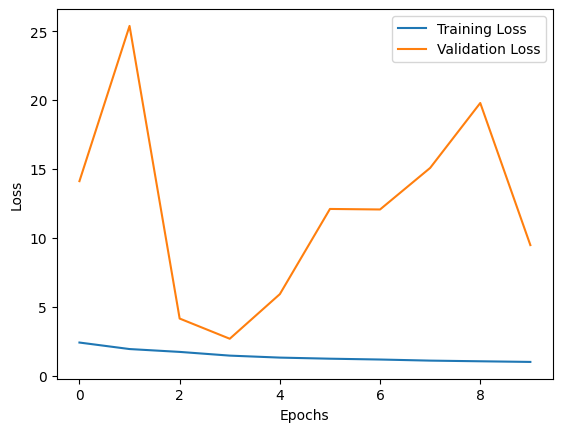

In [14]:
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

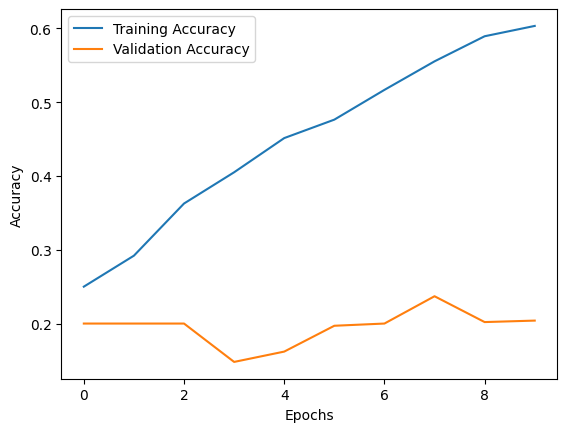

In [15]:
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()